In [1]:
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import textalloc as ta
import seaborn as sns
import numpy as np

In [2]:
cluster1_allTime = pd.read_excel("./data/DEG AMC June25.xlsx",sheet_name='DEG cluster 1 of P1,P4 all Time')
cluster1_multi = pd.read_excel("./data/DEG AMC June25.xlsx",sheet_name='DEG cluster 1, P1,P4, SandM')
cluster0_multi = pd.read_excel("./data/DEG AMC June25.xlsx",sheet_name='DEG cluster 0, P1,P4 SandM')
cluster5 = pd.read_csv("./data/DEG_cluster5.csv")

In [3]:
cluster5

,gene,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster
0,APOBEC3G,1.500000e-08,0.876,0.769,0.263,0.000212,5
1,PTPRC,2.470000e-08,0.823,1.000,0.988,0.000349,5
2,CCL5,6.570000e-08,1.260,0.962,0.467,0.000929,5
3,ARHGAP26,1.040000e-07,0.452,0.462,0.097,0.001470,5
4,XCL2,1.140000e-07,0.383,0.308,0.039,0.001610,5
5,CST7,1.400000e-07,0.942,0.962,0.471,0.001980,5
6,CD8A,2.680000e-07,0.894,1.000,0.780,0.003780,5
7,LDHB,5.000000e-07,-0.927,0.615,0.884,0.007070,5
8,LTB,8.260000e-07,-1.320,0.154,0.660,0.011700,5
9,SEPTIN11,1.950000e-06,0.305,0.231,0.027,0.027600,5


In [4]:
def format_deg_df(df):
    """
    Renames DEG DataFrame columns to standard names and sets 'gene' as index.

    Changes:
    - 'avg_log2FC' → 'log2FoldChange'
    - 'p_val_adj' → 'padj'
    - Sets 'gene' column as index (if present)

    Parameters:
    - df (pd.DataFrame): Input DataFrame with DEG results

    Returns:
    - pd.DataFrame: Cleaned and reformatted DataFrame
    """
    df = df.rename(columns={
        'avg_log2FC': 'log2FoldChange',
        'p_val_adj': 'padj',
        'gene':'gene_name'
    })
    return df


In [5]:
cluster0_multi = format_deg_df(cluster0_multi)
cluster1_multi = format_deg_df(cluster1_multi)
cluster1_allTime = format_deg_df(cluster1_allTime)
cluster5 = format_deg_df(cluster5)

In [6]:
cluster1_multi

,Unnamed: 0,gene_name,p_val,log2FoldChange,pct.1,pct.2,padj,cluster
0,1,RPS26,3.799428e-42,-2.290327,0.794,1.000,5.372772e-38,1
1,2,RPS27,2.904838e-34,-0.726624,1.000,1.000,4.107731e-30,1
2,3,S100A11,3.735317e-19,-1.796843,0.429,0.820,5.282112e-15,1
3,4,IFITM1,4.345317e-19,1.524436,0.952,0.715,6.144713e-15,1
4,5,MX1,3.230422e-17,2.091808,0.683,0.268,4.568139e-13,1
...,...,...,...,...,...,...,...,...
57,58,PSMB8,1.788586e-06,0.811216,0.738,0.522,2.529240e-02,1
58,59,OASL,1.789837e-06,1.681581,0.254,0.070,2.531009e-02,1
59,60,ANXA5,1.997458e-06,-2.144390,0.056,0.263,2.824606e-02,1
60,61,NCK2,2.747467e-06,1.481215,0.349,0.140,3.885193e-02,1


In [ ]:
def volcano_matplotlib_with_textalloc(df, cutoff_fc=0.58, cutoff_p=0.001, highlight_n=10, height=9, width=10, x_range=None,save=None,title="Volcano Plot"):
    """
    Function to create a volcano plot with Matplotlib and label the most important genes using textalloc.

    Parameters:
    df : DataFrame
        DataFrame containing columns 'log2FoldChange', 'padj', and 'gene_name'.
    cutoff_fc : float, optional
        Fold-change cutoff for determining significance. Default is 1.
    cutoff_p : float, optional
        p-value cutoff for determining significance. Default is 0.001.
    highlight_n : int, optional
        Number of genes to highlight on the plot by labeling the most important genes.
    height : float, optional
        Height of the plot in inches. Default is 9.
    width : float, optional
        Width of the plot in inches. Default is 10.
    x_range : tuple, optional
        Range for the x-axis (log2FoldChange). Default is None (auto).

    Returns:
    Matplotlib figure and axis
    """

    # Prepare data for coloring and labeling
    df['keyvals.colour'] = np.where(
        (df['log2FoldChange'] < -cutoff_fc) & (df['padj'] < cutoff_p), 'blue',
        np.where((df['log2FoldChange'] > cutoff_fc) & (df['padj'] < cutoff_p), 'red', 'grey')
    )
    df['keyvals.label'] = np.where(
        (df['log2FoldChange'] < -cutoff_fc) & (df['padj'] < cutoff_p), 'Down regulated',
        np.where((df['log2FoldChange'] > cutoff_fc) & (df['padj'] < cutoff_p), 'Up regulated', 'NS')
    )
    df['-log10(padj)'] = -np.log10(df['padj'])

    # Identify the most important genes
    most_important_genes = df[(df['padj'] < cutoff_p) & (df['log2FoldChange'].abs() > cutoff_fc)]\
        .sort_values(by='padj').head(highlight_n)

    # Initialize the plot
    plt.figure(figsize=(width, height))
    sns.set_style("ticks")

    # Scatter plot
    plt.scatter(df['log2FoldChange'], df['-log10(padj)'], c=df['keyvals.colour'], alpha=0.7, edgecolor=None)

    # Highlight most important genes
    plt.scatter(most_important_genes['log2FoldChange'], most_important_genes['-log10(padj)'],
                c=most_important_genes['keyvals.colour'], s=100)

    # Add cutoff lines
    plt.axhline(-np.log10(cutoff_p), color='black', linestyle='--', linewidth=0.8, label=f'Cutoff: p={cutoff_p}')
    plt.axvline(cutoff_fc, color='black', linestyle='--', linewidth=0.8, label=f'Cutoff: FC={round(np.exp2(cutoff_fc),1)}')
    plt.axvline(-cutoff_fc, color='black', linestyle='--', linewidth=0.8)
    
    # Use textalloc for better label placement
    ax = plt.gca()
    ta.allocate(
        ax,
        most_important_genes['log2FoldChange'].values,
        most_important_genes['-log10(padj)'].values,
        most_important_genes['gene_name'].values,
        x_scatter=df['log2FoldChange'].values,
        y_scatter=df['-log10(padj)'].values,
        max_distance=0.07,
    )
    # set fontsize only on the gene label texts
    gene_names = set(most_important_genes['gene_name'].values)
    for txt in ax.texts:                       
        if txt.get_text() in gene_names:
            txt.set_fontsize(18)
    

    # Customize plot
    plt.title(title, fontsize=14)
    plt.xlabel('log2FoldChange', fontsize=22)
    plt.ylabel('-log10(padj)', fontsize=22)
    if x_range:
        plt.xlim(x_range)
    plt.ylim(0, df['-log10(padj)'].max() + 2)
    plt.legend(loc='upper right', fontsize=16)
    plt.tight_layout()
    if save:
        plt.savefig(save)
    # Show plot
    plt.show()

In [8]:
plt.rcParams["font.size"] = 16         # general font size

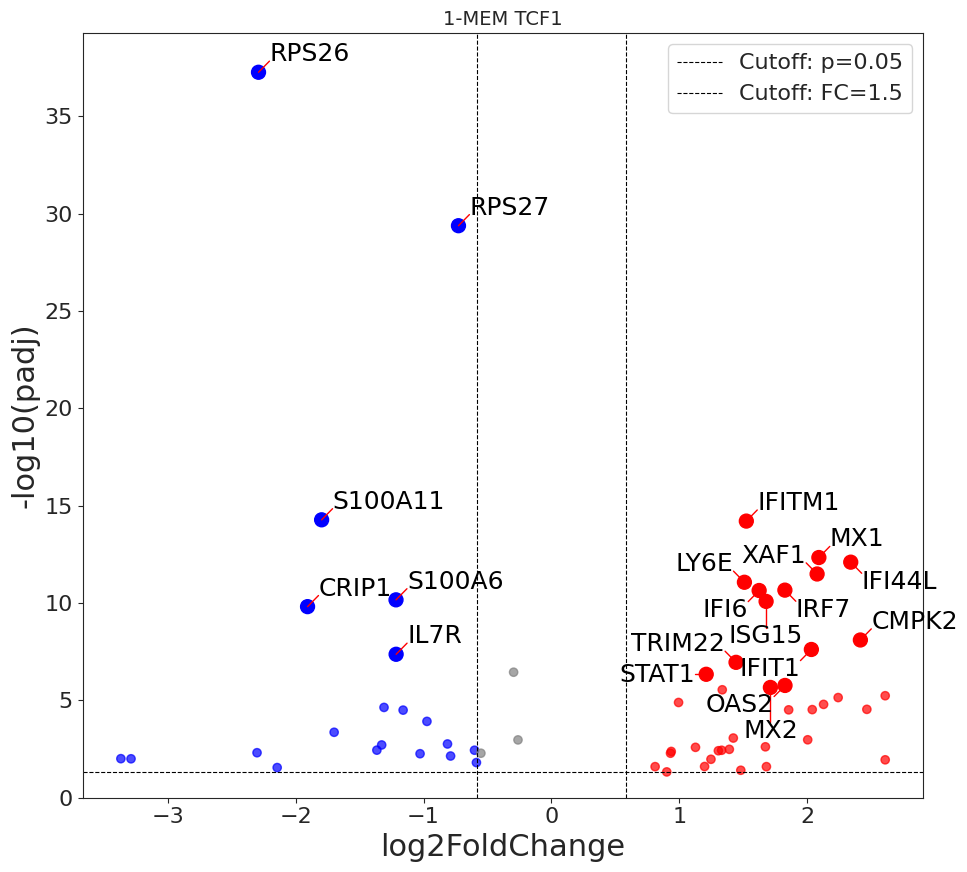

In [15]:
volcano_matplotlib_with_textalloc(cluster1_multi,highlight_n=20,cutoff_p=0.05,title='1-MEM TCF1',save="./figures/volcano_plot/cluster1_SandM")

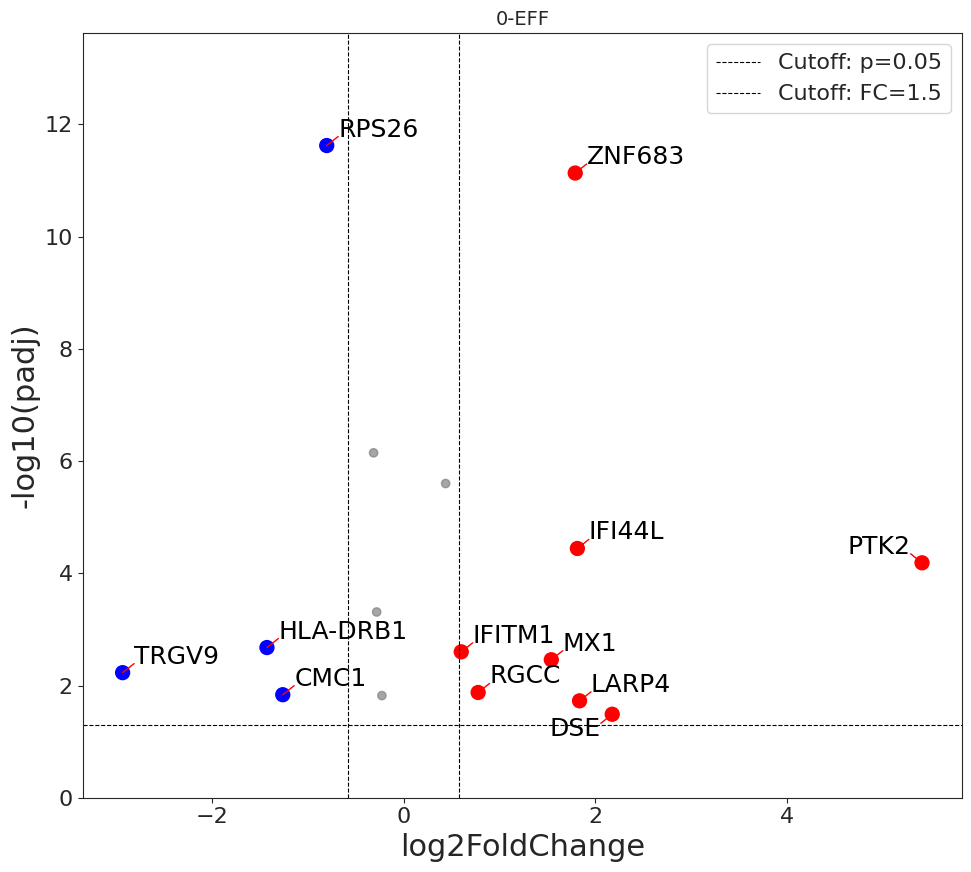

In [16]:
volcano_matplotlib_with_textalloc(cluster0_multi,highlight_n=30,cutoff_p=0.05,title='0-EFF',save="./figures/volcano_plot/cluster0_SandM")

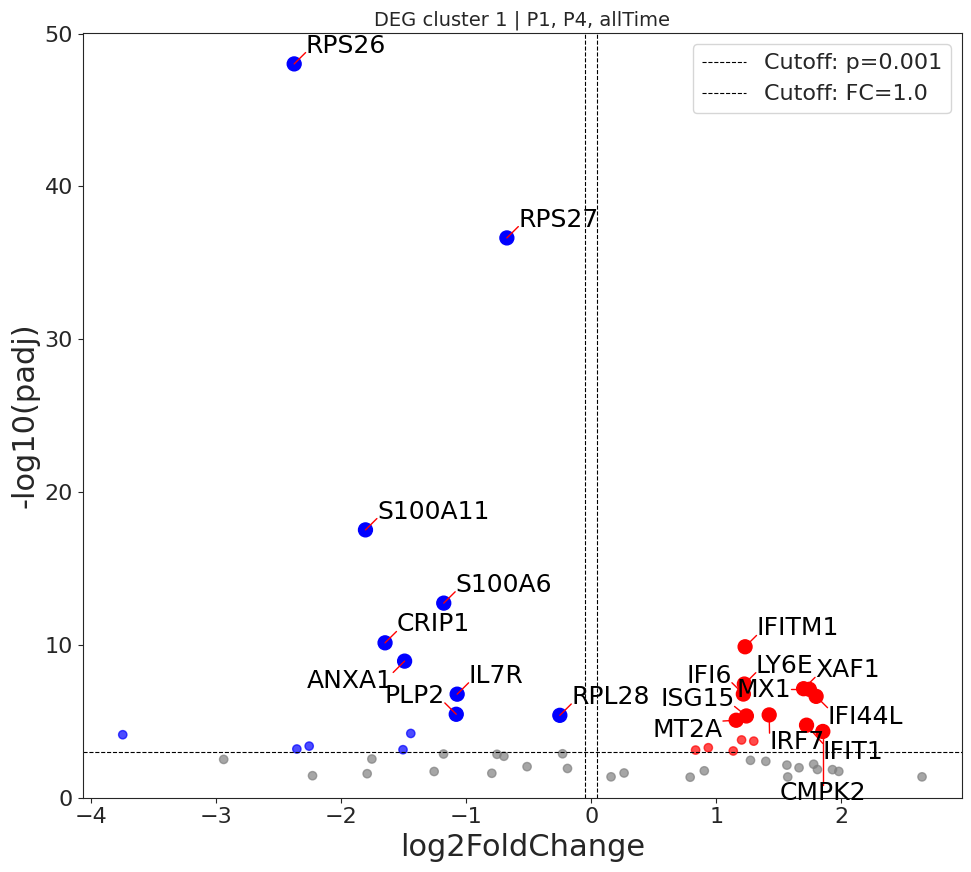

In [13]:
volcano_matplotlib_with_textalloc(cluster1_allTime,highlight_n=20,cutoff_fc=0.05,title='DEG cluster 1 | P1, P4, allTime',save="./figures/volcano_plot/cluster1_AllTime")

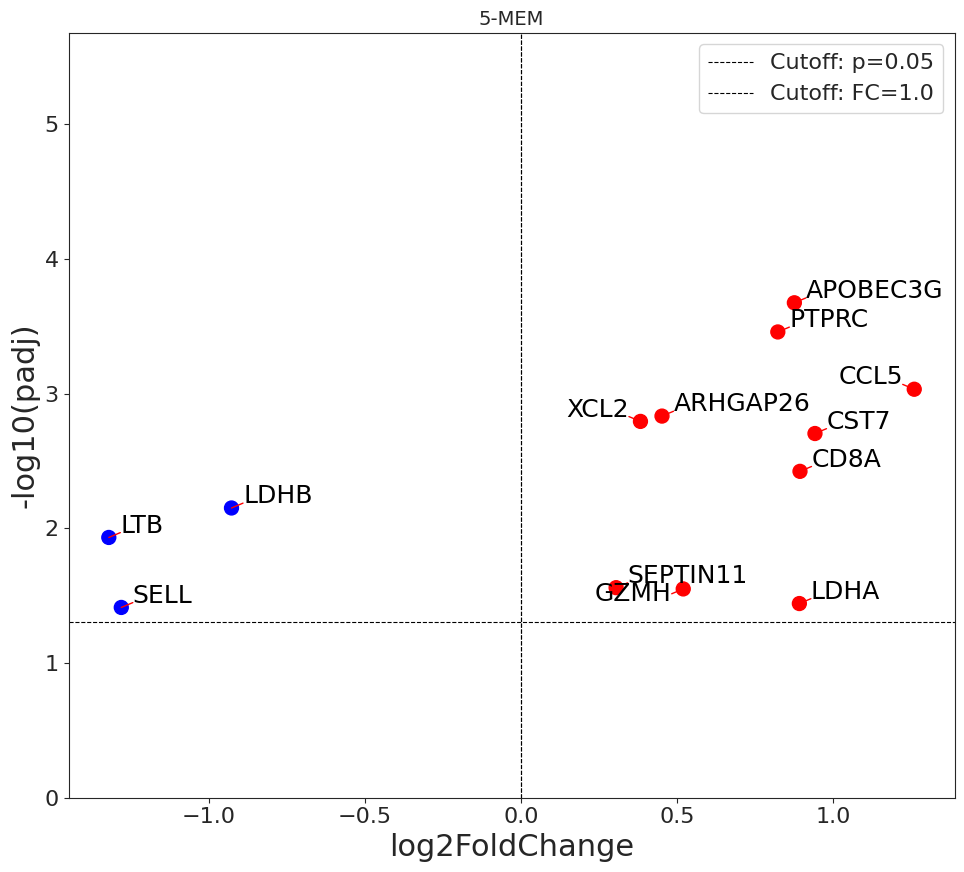

In [17]:
volcano_matplotlib_with_textalloc(cluster5,highlight_n=20,cutoff_p=0.05,cutoff_fc=0,title='5-MEM',save="./figures/article/cluster5_noFCcutoff")